<a href="https://colab.research.google.com/github/xherry24/aleena/blob/main/healthcareproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import os

from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
)

#Upload ZIP File
print("Please upload your ZIP file containing the dataset (e.g., heart_failure.zip)")
uploaded = files.upload()

#Extract ZIP File
for filename in uploaded.keys():
    zip_filename = filename
    print(f"\n Uploaded File: {zip_filename}")

# Extract the ZIP
with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    zip_ref.extractall("dataset")
print("Dataset extracted successfully!")

# Check extracted files
print("\n Extracted files:")
os.listdir("dataset")

Please upload your ZIP file containing the dataset (e.g., heart_failure.zip)


Saving archive (4).zip to archive (4).zip

 Uploaded File: archive (4).zip
Dataset extracted successfully!

 Extracted files:


['heart_failure_clinical_records_dataset.csv']

In [ ]:
#Load the Dataset (update name if different)
#For example, if file is named 'heart_failure_clinical_records_dataset.csv'
csv_files = [f for f in os.listdir("dataset") if f.endswith(".csv")]
if len(csv_files) == 0:
    raise FileNotFoundError("No CSV file found inside the ZIP! Please check the ZIP contents.")

data_path = os.path.join("dataset", csv_files[0])
data = pd.read_csv(data_path)
print("\nDataset Loaded Successfully!")
print(data.head())

#Basic Data Understanding
print("\nDataset Info:")
print(data.info())
print("\nMissing Values:")
print(data.isnull().sum())
print("\nTarget Variable Distribution:")
if 'DEATH_EVENT' not in data.columns:
    raise KeyError("Column 'DEATH_EVENT' not found in dataset! Please verify CSV column names.")
print(data['DEATH_EVENT'].value_counts())





Dataset Loaded Successfully!
    age  anaemia  creatinine_phosphokinase  diabetes  ejection_fraction  \
0  75.0        0                       582         0                 20   
1  55.0        0                      7861         0                 38   
2  65.0        0                       146         0                 20   
3  50.0        1                       111         0                 20   
4  65.0        1                       160         1                 20   

   high_blood_pressure  platelets  serum_creatinine  serum_sodium  sex  \
0                    1  265000.00               1.9           130    1   
1                    0  263358.03               1.1           136    1   
2                    0  162000.00               1.3           129    1   
3                    0  210000.00               1.9           137    1   
4                    0  327000.00               2.7           116    0   

   smoking  time  DEATH_EVENT  
0        0     4            1  
1        0

In [ ]:
#Data Preprocessing
X = data.drop('DEATH_EVENT', axis=1)
y = data['DEATH_EVENT']

# Normalize numeric columns
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)
print("\nData Split Done:")
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])




Data Split Done:
Training samples: 209
Testing samples: 90


In [ ]:
#Model Training
#Logistic Regression
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test)
y_prob_lr = log_reg.predict_proba(X_test)[:, 1]

# Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

# 8️⃣ Model Evaluation
def evaluate_model(y_test, y_pred, y_prob, model_name):
    print(f"\n📊 {model_name} Evaluation:")
    print(classification_report(y_test, y_pred))
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    print(f"Accuracy: {acc:.4f}, ROC-AUC: {auc:.4f}")
    return acc, auc

acc_lr, auc_lr = evaluate_model(y_test, y_pred_lr, y_prob_lr, "Logistic Regression")
acc_rf, auc_rf = evaluate_model(y_test, y_pred_rf, y_prob_rf, "Random Forest")


📊 Logistic Regression Evaluation:
              precision    recall  f1-score   support

           0       0.85      0.92      0.88        61
           1       0.79      0.66      0.72        29

    accuracy                           0.83        90
   macro avg       0.82      0.79      0.80        90
weighted avg       0.83      0.83      0.83        90

Accuracy: 0.8333, ROC-AUC: 0.8643

📊 Random Forest Evaluation:
              precision    recall  f1-score   support

           0       0.84      0.92      0.88        61
           1       0.78      0.62      0.69        29

    accuracy                           0.82        90
   macro avg       0.81      0.77      0.78        90
weighted avg       0.82      0.82      0.82        90

Accuracy: 0.8222, ROC-AUC: 0.8847


In [ ]:
# ✅ Logistic Regression Hyperparameter Tuning using GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score

log_reg = LogisticRegression(max_iter=1000)

param_grid_lr = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear', 'lbfgs'],
    'penalty': ['l2'],   # 'l1' works only with 'liblinear'
    'class_weight': [None, 'balanced']
}

grid_lr = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid_lr,
    cv=5,
    scoring='f1',
    verbose=2,
    n_jobs=-1
)

grid_lr.fit(X_train, y_train)

best_lr = grid_lr.best_estimator_
print("Best Logistic Regression Parameters:", grid_lr.best_params_)

# Evaluate tuned Logistic Regression
y_pred_lr = best_lr.predict(X_test)
y_prob_lr = best_lr.predict_proba(X_test)[:, 1]

print("\n📊 Logistic Regression Evaluation After Tuning:")
print(classification_report(y_test, y_pred_lr))
tuned_acc_lr = accuracy_score(y_test, y_pred_lr)
tuned_auc_lr = roc_auc_score(y_test, y_prob_lr)
print("Accuracy:", round(tuned_acc_lr, 4))
print("ROC-AUC:", round(tuned_auc_lr, 4))

# ✅ Random Forest Hyperparameter Tuning using RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

rf = RandomForestClassifier(random_state=42)

param_dist_rf = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 5, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'class_weight': [None, 'balanced']
}

random_search_rf = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist_rf,
    n_iter=30,   # number of random combinations to try
    cv=5,
    scoring='f1',
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search_rf.fit(X_train, y_train)

best_rf = random_search_rf.best_estimator_
print("\nBest Random Forest Parameters:", random_search_rf.best_params_)

# Evaluate tuned Random Forest
y_pred_rf = best_rf.predict(X_test)
y_prob_rf = best_rf.predict_proba(X_test)[:, 1]

print("\n📊 Random Forest Evaluation After Tuning:")
print(classification_report(y_test, y_pred_rf))
tuned_acc_rf = accuracy_score(y_test, y_pred_rf)
tuned_auc_rf = roc_auc_score(y_test, y_prob_rf)
print("Accuracy:", round(tuned_acc_rf, 4))
print("ROC-AUC:", round(tuned_auc_rf, 4))

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best Logistic Regression Parameters: {'C': 0.01, 'class_weight': None, 'penalty': 'l2', 'solver': 'liblinear'}

📊 Logistic Regression Evaluation After Tuning:
              precision    recall  f1-score   support

           0       0.84      0.92      0.88        61
           1       0.78      0.62      0.69        29

    accuracy                           0.82        90
   macro avg       0.81      0.77      0.78        90
weighted avg       0.82      0.82      0.82        90

Accuracy: 0.8222
ROC-AUC: 0.8734
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best Random Forest Parameters: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': None, 'class_weight': 'balanced'}

📊 Random Forest Evaluation After Tuning:
              precision    recall  f1-score   support

           0       0.85      0.92      0.88        61
           1       0.79      0.66  

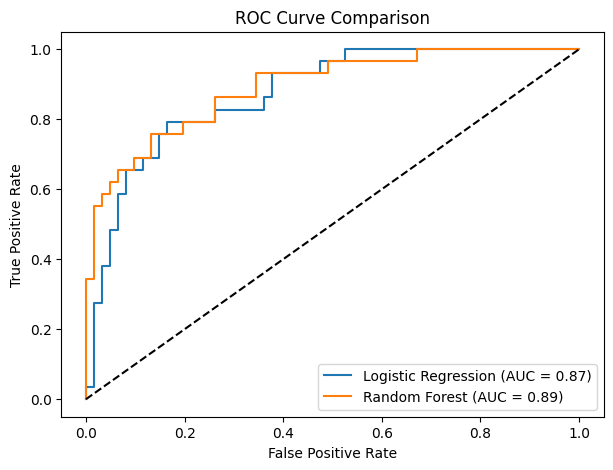

/tmp/ipython-input-251197178.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importances, palette="viridis")


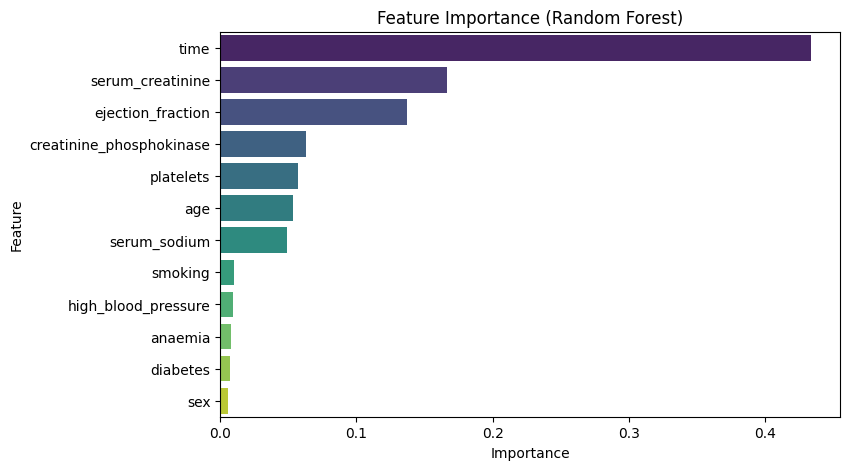

/tmp/ipython-input-251197178.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y="Accuracy", data=comparison, palette="Set2")



📈 Model Comparison:

                 Model  Accuracy   ROC-AUC
0  Logistic Regression  0.822222  0.873375
1        Random Forest  0.833333  0.890334


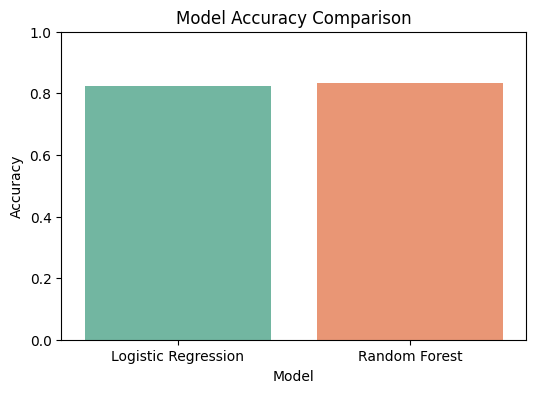

In [ ]:
# 9️⃣ ROC Curve
plt.figure(figsize=(7,5))
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {tuned_auc_lr:.2f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {tuned_auc_rf:.2f})")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

# 🔟 Feature Importance (Random Forest)
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x='Importance', y='Feature', data=feature_importances, palette="viridis")
plt.title("Feature Importance (Random Forest)")
plt.show()

# 1️⃣1️⃣ Model Comparison
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [tuned_acc_lr, tuned_acc_rf],
    "ROC-AUC": [tuned_auc_lr, tuned_auc_rf]
})
print("\n📈 Model Comparison:\n")
print(comparison)

plt.figure(figsize=(6,4))
sns.barplot(x="Model", y="Accuracy", data=comparison, palette="Set2")
plt.title("Model Accuracy Comparison")
plt.ylim(0, 1)
plt.show()

In [ ]:
# Install required libs (Colab)
!pip install xgboost imbalanced-learn shap --quiet

# Imports (additions)
from imblearn.over_sampling import SMOTE
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import StratifiedKFold, cross_val_score
import xgboost as xgb
import joblib
import shap
from sklearn.calibration import calibration_curve
from sklearn.metrics import precision_recall_curve, auc

In [ ]:
# Check column types and unique values to be sure
print(data.dtypes)
for col in ['anaemia','diabetes','high_blood_pressure','sex','smoking']:
    if col in data.columns:
        print(col, data[col].unique())

# Example if any categorical is string (likely not needed for UCI dataset)
cat_cols = ['sex','anaemia','diabetes','high_blood_pressure','smoking']
for c in cat_cols:
    if data[c].dtype == 'object':
        data[c] = data[c].map({'yes':1,'no':0})  # adjust mapping as required

age                         float64
anaemia                       int64
creatinine_phosphokinase      int64
diabetes                      int64
ejection_fraction             int64
high_blood_pressure           int64
platelets                   float64
serum_creatinine            float64
serum_sodium                  int64
sex                           int64
smoking                       int64
time                          int64
DEATH_EVENT                   int64
dtype: object
anaemia [0 1]
diabetes [0 1]
high_blood_pressure [1 0]
sex [1 0]
smoking [0 1]


In [ ]:
# Define numeric and categorical columns
numeric_cols = ['age','creatinine_phosphokinase','ejection_fraction','platelets','serum_creatinine','serum_sodium','time']
binary_cols = ['anaemia','diabetes','high_blood_pressure','sex','smoking']  # already 0/1

# Column transformer: scale numeric, passthrough binary
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('bin', 'passthrough', binary_cols)
    ]
)

# Create a training pipeline: preprocessing -> SMOTE -> model
smote = SMOTE(random_state=42)

# Example pipeline for XGBoost (we will do resampling manually inside training step)
from imblearn.pipeline import Pipeline as ImbPipeline

xgb_clf = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

pipeline_xgb = ImbPipeline(steps=[
    ('pre', preprocessor),
    ('smote', smote),
    ('clf', xgb_clf)
])

# Convert X_train and X_test back to DataFrames for ColumnTransformer
X_train_df = pd.DataFrame(X_train, columns=X.columns)
X_test_df = pd.DataFrame(X_test, columns=X.columns)

# Fit
pipeline_xgb.fit(X_train_df, y_train)
y_prob_xgb = pipeline_xgb.predict_proba(X_test_df)[:,1]
y_pred_xgb = pipeline_xgb.predict(X_test_df)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [15:55:28] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
X = data.drop('DEATH_EVENT', axis=1)
y = data['DEATH_EVENT']
# keep column order
X_df = X.copy()
X_train_df, X_test_df, y_train, y_test = train_test_split(X_df, y, test_size=0.3, stratify=y, random_state=42)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Wrap logistic + rf pipelines similarly (example shown for logistic)
log_pipeline = ImbPipeline(steps=[
    ('pre', preprocessor),
    # optional SMOTE: ('smote', smote),
    ('clf', LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'))
])

scores = cross_val_score(log_pipeline, X_df, y, cv=skf, scoring='roc_auc', n_jobs=-1)
print("Logistic CV ROC-AUC:", scores.mean(), scores.std())

# same for RF and XGB
rf_pipeline = ImbPipeline(steps=[('pre', preprocessor), ('smote', smote), ('clf', RandomForestClassifier(n_estimators=200, random_state=42))])
xgb_pipeline = ImbPipeline(steps=[('pre', preprocessor), ('smote', smote), ('clf', xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42))])

for name, pipe in [('LogReg', log_pipeline), ('RF', rf_pipeline), ('XGB', xgb_pipeline)]:
    s = cross_val_score(pipe, X_df, y, cv=skf, scoring='f1', n_jobs=-1)
    print(name, "CV F1:", round(s.mean(),4), "+/-", round(s.std(),4))

Logistic CV ROC-AUC: 0.8779537869062899 0.032688524348050446
LogReg CV F1: 0.7102 +/- 0.0235
RF CV F1: 0.7338 +/- 0.0756
XGB CV F1: 0.7342 +/- 0.05


Fitting 5 folds for each of 20 candidates, totalling 100 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [15:58:09] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_nanfunctions_impl.py:1424: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(


Best XGB params: {'clf__subsample': 0.6, 'clf__n_estimators': 50, 'clf__max_depth': 7, 'clf__learning_rate': 0.05, 'clf__colsample_bytree': 0.6}


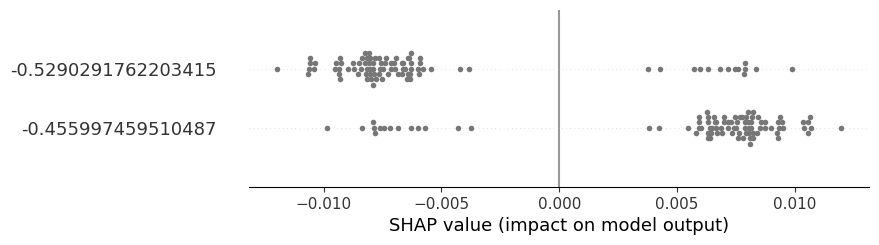

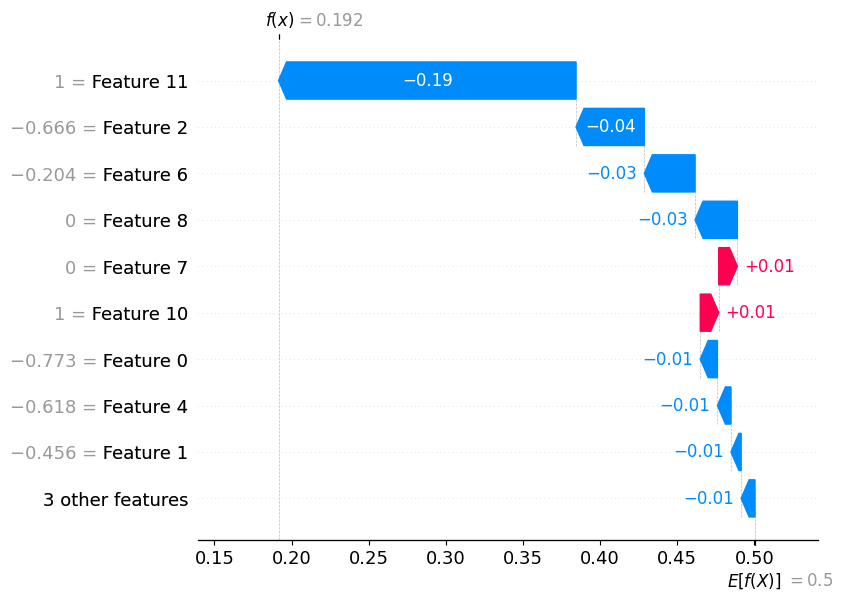

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

params_xgb = {
    'clf__n_estimators': [50, 100, 200, 300],
    'clf__max_depth': [3,5,7,10],
    'clf__learning_rate': [0.01, 0.05, 0.1],
    'clf__subsample': [0.6, 0.8, 1.0],
    'clf__colsample_bytree': [0.6, 0.8, 1.0]
}

rnd_xgb = RandomizedSearchCV(xgb_pipeline, param_distributions=params_xgb, n_iter=20, scoring='f1', cv=skf, n_jobs=-1, verbose=2, random_state=42)
rnd_xgb.fit(X_train_df, y_train)
print("Best XGB params:", rnd_xgb.best_params_)
best_xgb = rnd_xgb.best_estimator_

# Create preprocessed training data to feed into SHAP (for tree models)
# X_train_pre = preprocessor.fit_transform(X_train_df) # This line is not needed for SHAP on the model directly

# For RandomForest / XGB you can use TreeExplainer
explainer = shap.Explainer(best_rf)  # Corrected: pass best_rf directly
# If pipeline used, pass transformed data
shap_values = explainer(preprocessor.transform(X_test_df))
# Select SHAP values for the positive class (class 1) for plotting
shap.plots.beeswarm(shap_values[:, 1])       # summary plot for class 1
shap.plots.waterfall(shap_values[0, :, 1])   # example for single sample, class 1

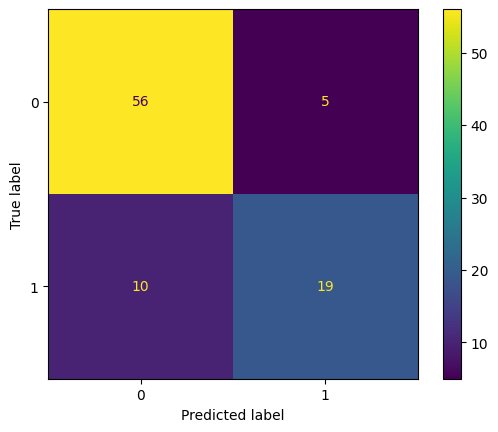

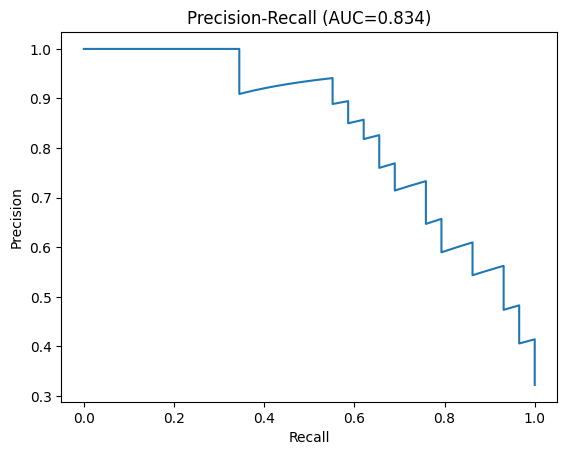

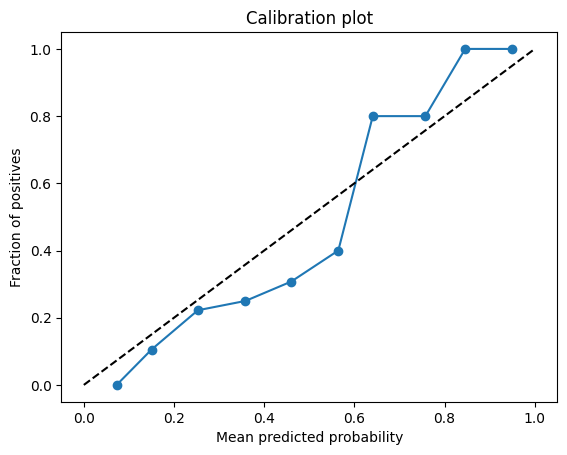

['best_logreg.joblib']

In [ ]:
def risk_bucket(prob):
    if prob < 0.25:
        return 'No risk'
    elif prob < 0.5:
        return 'Low'
    elif prob < 0.75:
        return 'Medium'
    else:
        return 'High'

probs = best_xgb.predict_proba(X_test_df)[:,1]
risk = [risk_bucket(p) for p in probs]
pd.Series(risk).value_counts()

import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, normalize=None)
plt.show()

# Precision-Recall
precision, recall, _ = precision_recall_curve(y_test, y_prob_rf)
pr_auc = auc(recall, precision)
plt.plot(recall, precision)
plt.title(f"Precision-Recall (AUC={pr_auc:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

# Calibration plot
prob_true, prob_pred = calibration_curve(y_test, y_prob_rf, n_bins=10)
plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1], [0,1], 'k--')
plt.title("Calibration plot")
plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.show()

joblib.dump(best_rf, 'best_random_forest.joblib')
joblib.dump(best_xgb, 'best_xgb.joblib')
joblib.dump(best_lr, 'best_logreg.joblib')